  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
   CustomerID  TotalQuantity  TotalSpend  Transactions  Cluster
0     12346.0          74215    77183.60             1        2
1     12347.0           2458     4310.00             7       

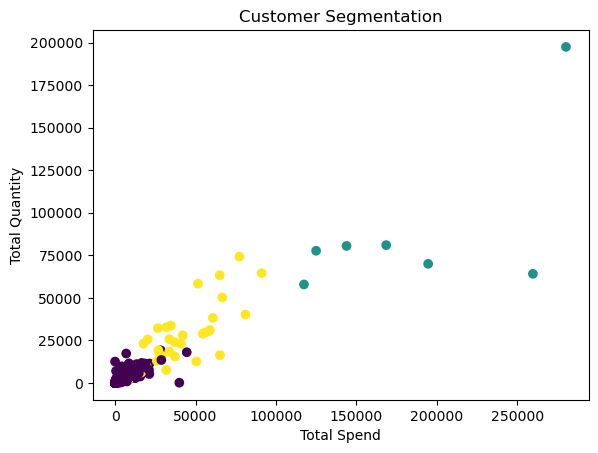

C:\Users\jegad\AppData\Local\Temp\ipykernel_10168\2236335289.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)
C:\Users\jegad\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                                          antecedents  \
31                   (PINK REGENCY TEACUP AND SAUCER)   
27  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...   
30                  (GREEN REGENCY TEACUP AND SAUCER)   
28  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...   
7                   (GREEN REGENCY TEACUP AND SAUCER)   

                                          consequents   support  confidence  \
31  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...  0.021040    0.701439   
27                   (PINK REGENCY TEACUP AND SAUCER)  0.021040    0.720887   
30  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...  0.021040    0.564399   
28                  (GREEN REGENCY TEACUP AND SAUCER)  0.021040    0.894495   
7                    (PINK REGENCY TEACUP AND SAUCER)  0.024817    0.665702   

         lift  
31  24.033032  
27  24.033032  
30  23.994742  
28  23.994742  
7   22.193256  
Project Completed Successfully!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
df = pd.read_excel("C:/Users/jegad/Downloads/online+retail/Online Retail.xlsx")
print(df.head())
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
customer_data = df.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()
customer_data.columns = ['CustomerID', 'TotalQuantity', 'TotalSpend', 'Transactions']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data[['TotalQuantity','TotalSpend','Transactions']])
kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(scaled_data)
print(customer_data.head())
plt.scatter(customer_data['TotalSpend'], customer_data['TotalQuantity'], c=customer_data['Cluster'])
plt.xlabel("Total Spend")
plt.ylabel("Total Quantity")
plt.title("Customer Segmentation")
plt.show()
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)
rules = rules.sort_values(by='lift', ascending=False)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())
customer_data.to_csv("customer_segments.csv", index=False)
rules.to_csv("association_rules.csv", index=False)
print("Project Completed Successfully!")